correlations between the Target variable and the discrete and categorical columns. 

!!! we need to do the dummy variables before this part. the results are okay but off 
because the target cariable was not included (mostly bc it's still a string and not a numerical variable)
(i'll work on this later orz)


the discrete columns are:
 
- Age at enrollment
- Curricular units 1st sem (credited)
- Curricular units 1st sem (enrolled)
- Curricular units 1st sem (evaluations)
- Curricular units 1st sem (approved)
- Curricular units 1st sem (without evaluations)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (evaluations)
- Curricular units 2nd sem (approved)
- Curricular units 2nd sem (without evaluations)

In [1]:
# load libraries and data
import pandas as pd
df = pd.read_csv('dropout_dataset.csv', sep=';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:
print("----------------------List of columns with discrete data")
# - planned analysis methods -> Chi-Square Test, Poisson Regression, Bar Charts/Histograms
df_discrete_columns = df[
    ['Age at enrollment', 'Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
     'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
     'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)',
     'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)',
     'Curricular units 2nd sem (without evaluations)'
    ]
]
print(df_discrete_columns.columns.tolist())

----------------------List of columns with discrete data
['Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (without evaluations)']


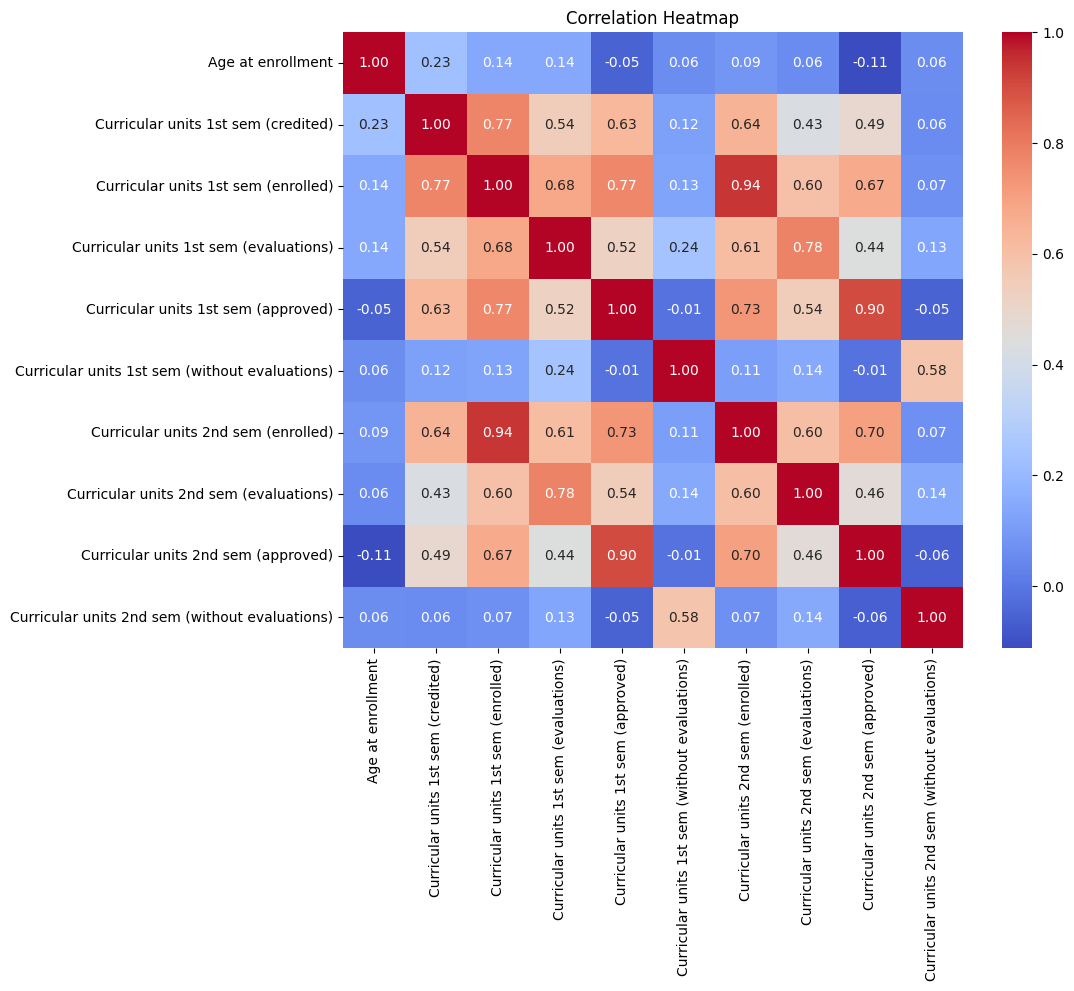

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix - only on discrete cols
corr = df_discrete_columns.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
# dataframe with discrete cols AND the target col
df_discrete_columns_and_target = df[
    ['Age at enrollment', 'Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)',
     'Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)',
     'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (enrolled)',
     'Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (approved)',
     'Curricular units 2nd sem (without evaluations)', 'Target'
    ]
]

In [13]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [14]:
# Chi-Square Test: association between 'Curricular units 1st sem (credited)' and 'Curricular units 1st sem (approved)'
ct = pd.crosstab(df['Curricular units 1st sem (credited)'], df['Curricular units 1st sem (approved)'])
chi2, p, dof, expected = chi2_contingency(ct)
print("Chi-Square Test between 'credited' and 'approved':")
print("Chi2 =", chi2, "| p-value =", p, "| degrees of freedom =", dof)


Chi-Square Test between 'credited' and 'approved':
Chi2 = 17802.33011676331 | p-value = 0.0 | degrees of freedom = 440


In [ ]:
from scipy.stats import chi2_contingency

def pairwise_chi2_tests(df, alpha=0.05):
    """
    Computes pairwise chi-square tests for all columns in the given DataFrame.
    Prints the results for pairs that show a statistically significant association.
    """
    cols = df.columns
    n = len(cols)
    for i in range(n):
        for j in range(i+1, n):
            col1, col2 = cols[i], cols[j]
            ct = pd.crosstab(df[col1], df[col2])
            chi2, p, dof, expected = chi2_contingency(ct)
            if p < alpha: # only statistically significant pairs are listed. i.e. p<0.05
                print(f"Chi-Square Test between '{col1}' and '{col2}':")
                print(f"Chi2 = {chi2} | p-value = {p} | degrees of freedom = {dof}\n")

pairwise_chi2_tests(df_discrete_columns)

Chi-Square Test between 'Age at enrollment' and 'Curricular units 1st sem (credited)':
Chi2 = 3088.3644490752686 | p-value = 4.5624788479207896e-237 | degrees of freedom = 900
This test shows overwhelming evidence against the null hypothesis, confirming a statistically significant association between the two variables
--------------------------------------------------------------------------------
Chi-Square Test between 'Age at enrollment' and 'Curricular units 1st sem (enrolled)':
Chi2 = 2618.953826269206 | p-value = 2.801805013961422e-147 | degrees of freedom = 990
This test shows overwhelming evidence against the null hypothesis, confirming a statistically significant association between the two variables
--------------------------------------------------------------------------------
Chi-Square Test between 'Age at enrollment' and 'Curricular units 1st sem (evaluations)':
Chi2 = 3053.563634442551 | p-value = 8.137252103643003e-104 | degrees of freedom = 1530
This test shows overwh

In [ ]:
# Poisson Regression: modeling 'Curricular units 1st sem (approved)' using other discrete columns as predictors
# mostly because we don't have dummy vars for the target col. will work on this later
predictors = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)', # currently used as target col. (so the results for this part don't count)
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (without evaluations)'
]

# what the regression should be about
# formula = 'Q("Target") ~ ' + ' + '.join(f'Q("{col}")' for col in predictors)

formula = 'Q("Curricular units 1st sem (approved)") ~ ' + ' + '.join(f'Q("{col}")' for col in predictors)
poisson_model = smf.glm(formula=formula, data=df, family=sm.families.Poisson()).fit()
print(poisson_model.summary())


                            Generalized Linear Model Regression Results                             
Dep. Variable:     Q("Curricular units 1st sem (approved)")   No. Observations:                 4424
Model:                                                  GLM   Df Residuals:                     4413
Model Family:                                       Poisson   Df Model:                           10
Link Function:                                          Log   Scale:                          1.0000
Method:                                                IRLS   Log-Likelihood:                -7623.8
Date:                                      Tue, 18 Feb 2025   Deviance:                       2278.3
Time:                                              04:41:36   Pearson chi2:                 1.70e+03
No. Iterations:                                           5   Pseudo R-squ. (CS):             0.8674
Covariance Type:                                  nonrobust                                

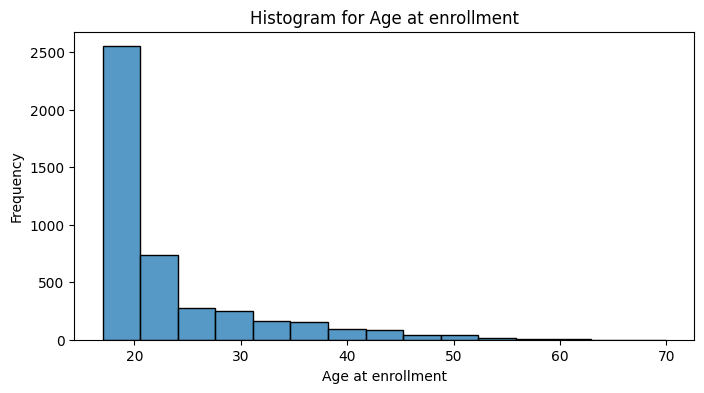

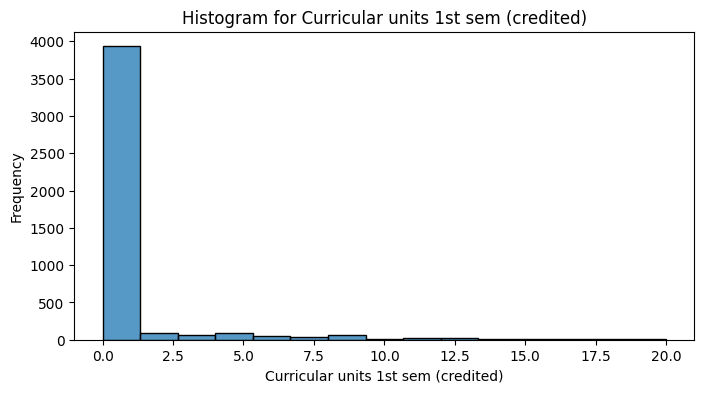

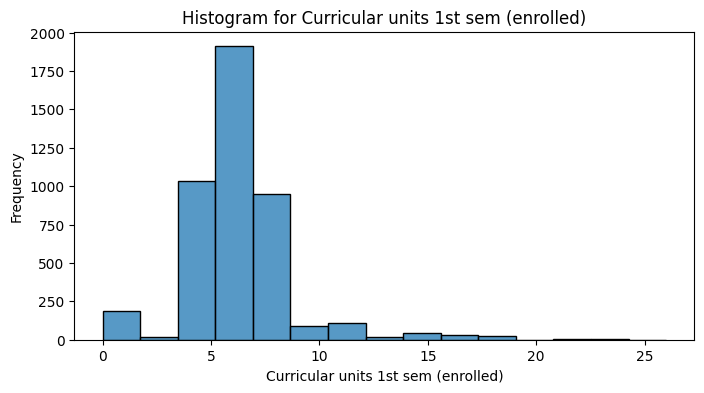

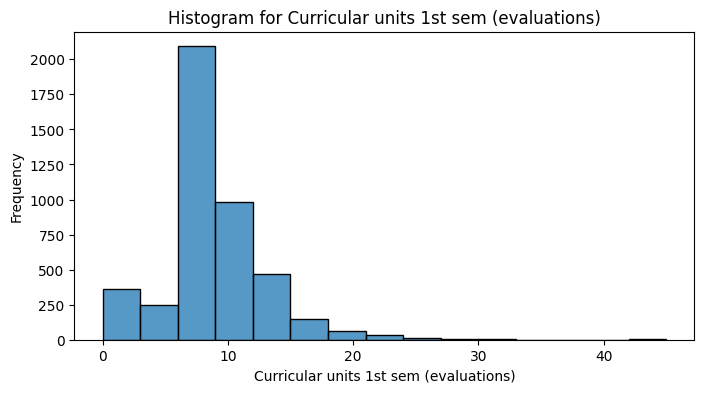

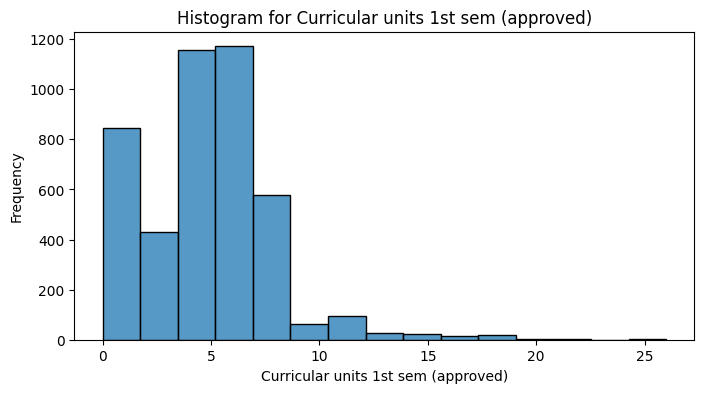

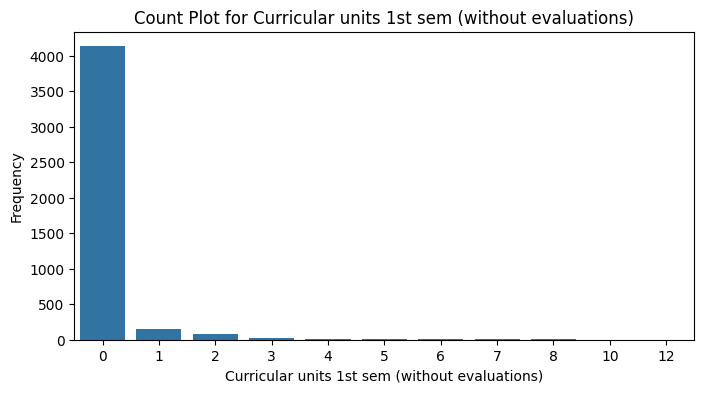

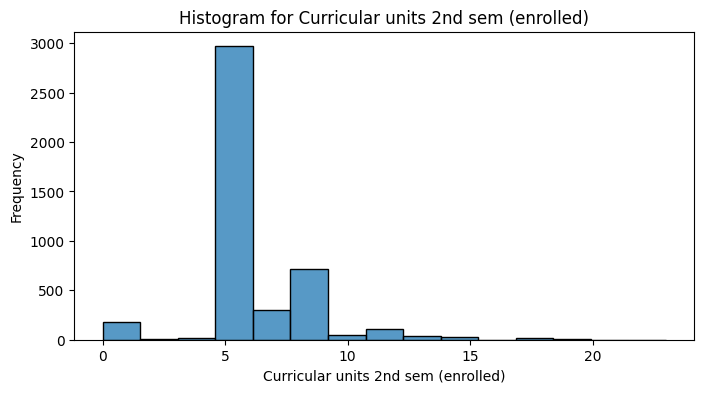

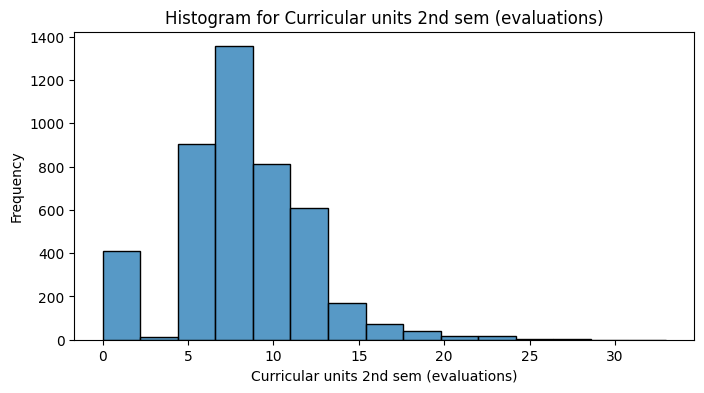

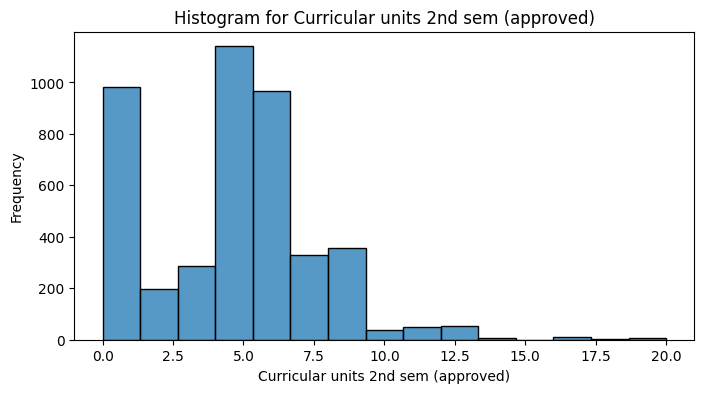

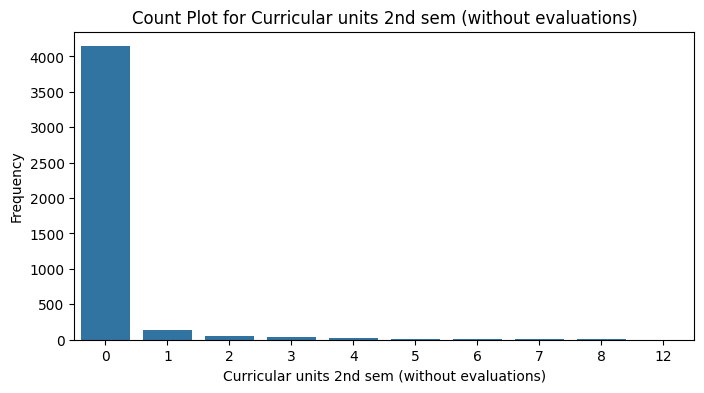

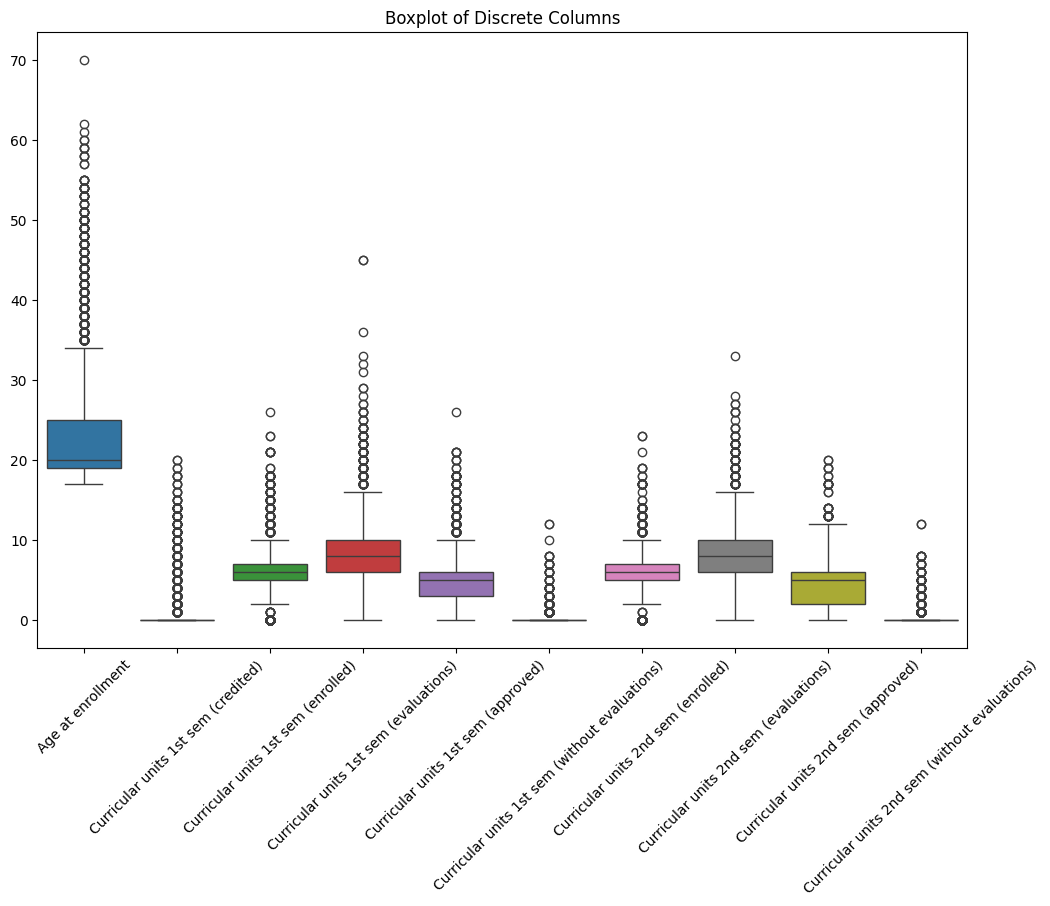

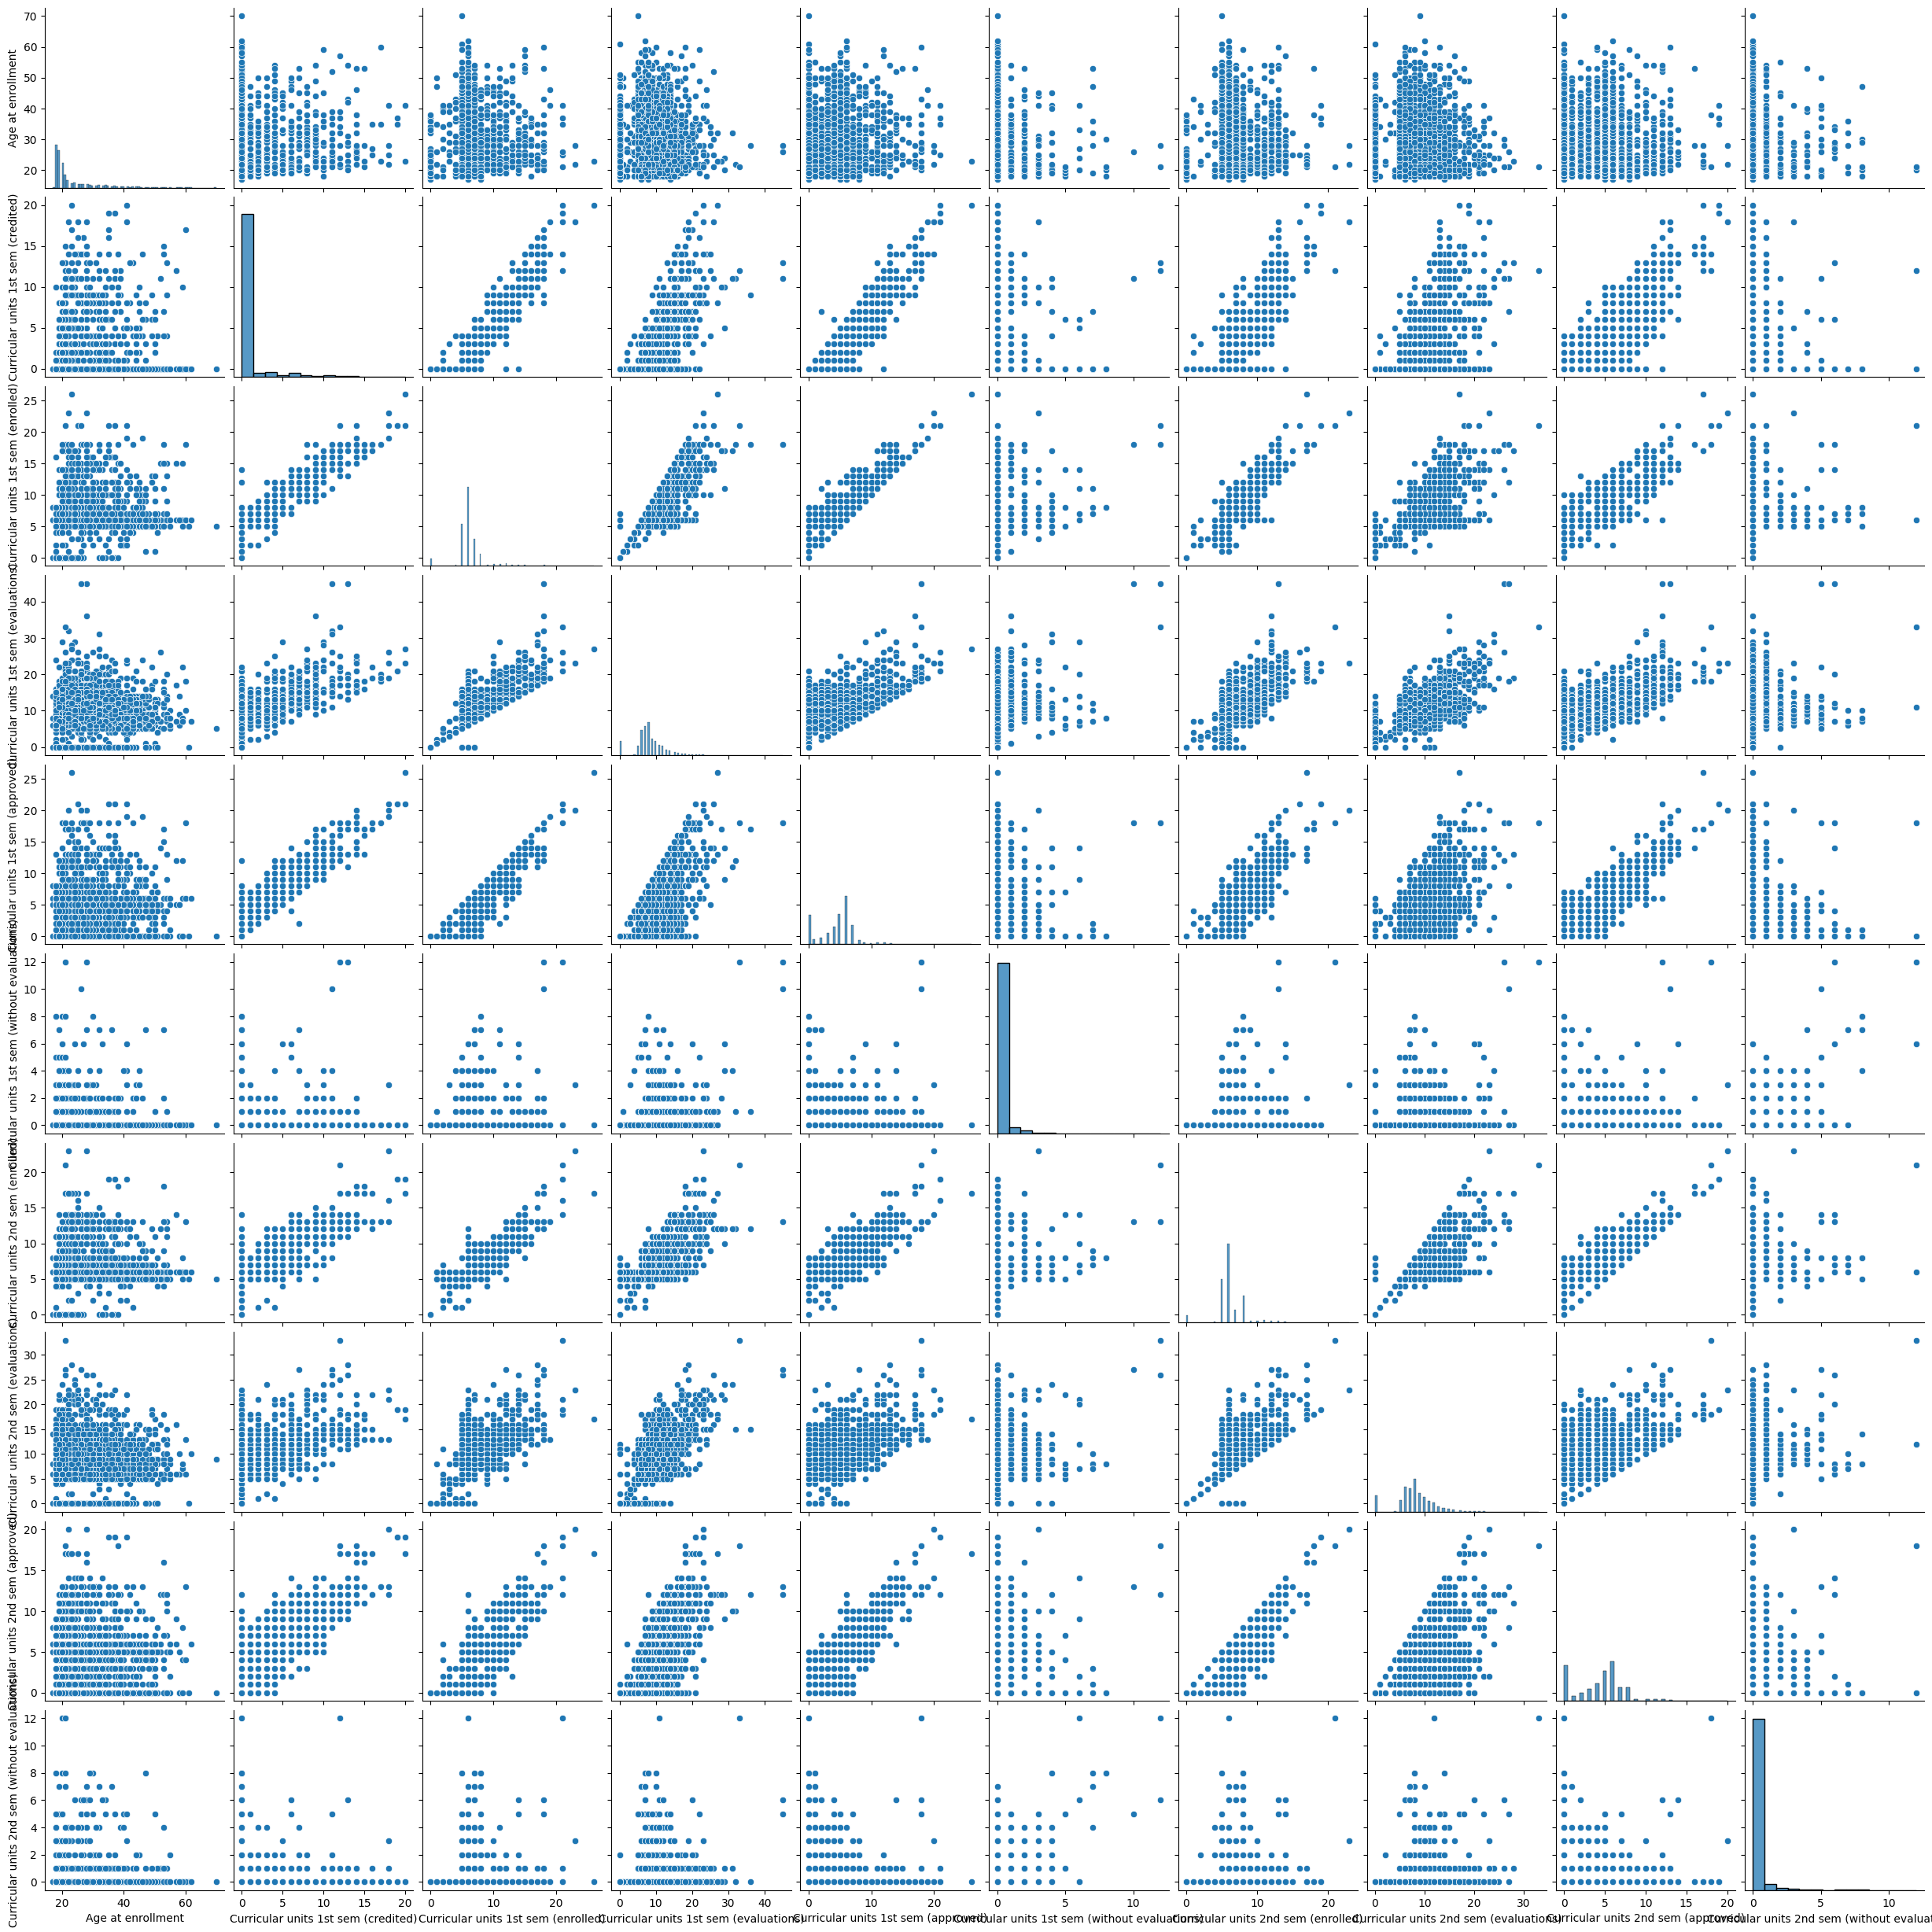

In [29]:
# For each discrete column, decide between a count plot (if few unique values) or histogram (if many unique values)
for col in df_discrete_columns.columns:
    plt.figure(figsize=(8, 4))
    if df_discrete_columns[col].nunique() < 15:
        sns.countplot(x=df_discrete_columns[col])
        plt.title(f'Count Plot for {col}')
    else:
        sns.histplot(df_discrete_columns[col], bins=15, kde=False)
        plt.title(f'Histogram for {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Boxplot for overall distribution of discrete columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_discrete_columns)
plt.xticks(rotation=45)
plt.title("Boxplot of Discrete Columns")
plt.show()

# Pairplot to visualize pairwise relationships
sns.pairplot(df_discrete_columns)
plt.show()


the categorical columns are: 

- Application mode
- Course
- Previous qualification
- Nacionality
- Target
- Mother's qualification
- Father's qualification